# VQE Ground-State Simulation of the Heisenberg Model

### Overview

This notebook demonstrates the Variational Quantum Eigensolver (VQE) implemented within many_body_qsim by approximating the ground state of the two-dimensional Heisenberg model. The VQE result is compared against exact diagonalization, and the resulting ground-state spin-spin correlation structure is visualized. The example illustrates how a variational quantum algorithm can recover physically meaningful observables in addition to ground-state energies.

### Imports

In [21]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from many_body_qsim.circuits import Quantum_Circuit
from many_body_qsim.lattices import square_lattice
from many_body_qsim.algorithms import vqe_energy, run_vqe
from many_body_qsim.hamiltonians import heisenberg_hamiltonian, string_to_operator, pauli_basis_to_matrix
from many_body_qsim.ansatz import hardware_efficient_ansatz
from many_body_qsim.observables import two_site_correlation, correlation_map, fidelity
from many_body_qsim.plotting import plot_correlation_map

### Construct the Heisenberg Hamiltonian

We begin by constructing a 3×2 square lattice and generating the isotropic Heisenberg Hamiltonian

$
H =
-J\sum_{\langle ij\rangle}
\left(
X_iX_j+
Y_iY_j+
Z_iZ_j
\right)
$

where the sum runs over nearest-neighbor lattice sites.

For this example: $J_x=J_y=J_z=-1$  corresponds to an antiferromagnetic interaction

In [22]:
Nx = 3
Ny = 2
N = Nx * Ny
bonds  = square_lattice(Nx, Ny)
H = heisenberg_hamiltonian(
    bonds, 
    Jx=-1, 
    Jy=-1, 
    Jz=-1, 
    h=0
)

### Constuct Exact Ground State

For validation, the exact ground state is obtained by diagonalizing the Hamiltonian:

$
H|\psi_0\rangle = E_0|\psi_0\rangle
$

where:

- $E_0$ is the exact ground-state energy
- $|\psi_0\rangle\$ is the exact ground-state wavefunction

Exact diagonalization provides a reference solution for evaluating the VQE approximation.

In [23]:
exact_eigen = np.linalg.eigh(pauli_basis_to_matrix(H))
exact_state_vector = exact_eigen[1][:, 0]
exact_ground_energy = exact_eigen[0][0]

### Variational Quantum Eigensolver

The VQE algorithm minimizes the expectation value of the Hamiltonian over a parameterized quantum circuit (ansatz). The optimized parameters approximate the ground-state wavefunction.

In [24]:
layers = 4

vqe_results = run_vqe(
    H, 
    ansatz=hardware_efficient_ansatz, 
    method='L-BFGS-B', 
    layers=layers
)

vqe_ground_energy = vqe_results.fun
optimal_params = vqe_results.x

### Energy Comparison

The optimized variational energy should closely reproduce the exact ground-state energy. Increasing the number of ansatz layers generally improves the approximation at the cost of additional optimization parameters.

In [25]:
print(f'Exact ground state energy: {exact_ground_energy}')
print(f'VQE ground state energy:   {vqe_ground_energy}')

Exact ground state energy: -12.517540966287267
VQE ground state energy:   -11.453934376145458


### Construct VQE Ground State

The optimized VQE parameters are used to prepare the variational ground state. The exact and variational statevectors are then compared using state fidelity.

In [26]:
psi = Quantum_Circuit(N) # Should match Hilbert dimension of model
exact_ground_state = psi.copy()
exact_ground_state.state = exact_state_vector

vqe_ground_state = hardware_efficient_ansatz(
    psi, 
    optimal_params, 
    layers=layers
)

state_fidelity = fidelity(
    exact_ground_state.state, 
    vqe_ground_state.state
)
print(f'State fidelity: {state_fidelity}')

State fidelity: 0.9023634036067583


### Spin-Spin Corrlation Maps

While VQE is designed to estimate the ground-state energy, once the optimized state has been prepared, any observable can be measured. Here we compute the equal-time spin-spin correlation matrix

$C_{ij}
=
\langle
\sigma_i^z\sigma_j^z
\rangle
$

and compare the spatial correlation structure recovered by VQE against the exact ground state.

In [27]:
corr_map_exact = correlation_map(axis='Z')(exact_ground_state)
corr_map_vqe = correlation_map(axis='Z')(vqe_ground_state)

### Visualization

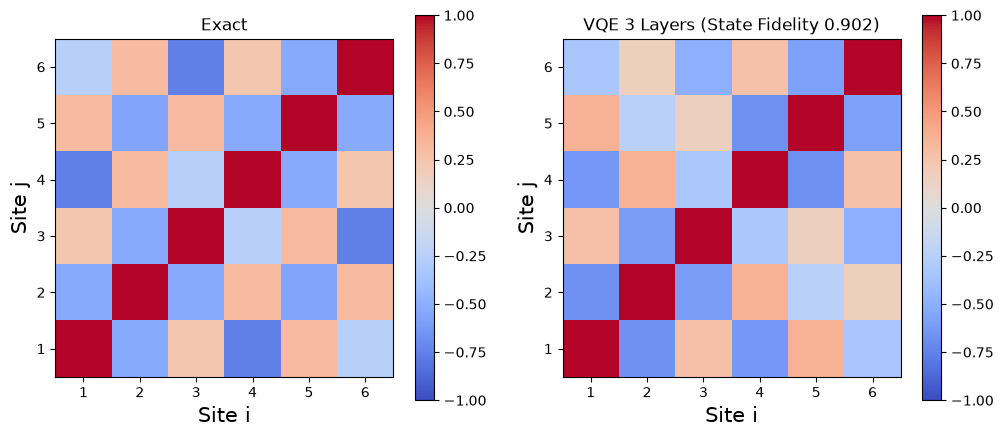

In [28]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5))

plot_correlation_map(corr_map_exact, xlabel = 'Site i', 
                     xlabel_fontsize=15, 
                     ylabel = 'Site j', 
                     ylabel_fontsize=15, 
                     title = 'Exact', 
                     title_fontsize=15,
                     vmin = -1, 
                     vmax = 1, 
                     ax = axs[0])
plot_correlation_map(corr_map_vqe, xlabel = 'Site i', 
                     xlabel_fontsize=15, 
                     ylabel = 'Site j', 
                     ylabel_fontsize=15, 
                     title = f'VQE {layers} Layers (State Fidelity {state_fidelity:.3f})', 
                     vmin = -1, 
                     vmax = 1, 
                     ax = axs[1])
plt.show()

### Discussion

The VQE approximation successfully reproduces both the ground-state energy and the spatial correlation structure of the Heisenberg model. Although the variational circuit contains only a finite number of parameters, the resulting correlation map closely matches the exact solution, demonstrating that the optimized state captures the essential many-body physics. This illustrates that VQE can be used not only to estimate ground-state energies but also to recover physically meaningful observables from the variationally prepared quantum state.